# Quick, Draw! Data Engineering

Before we can train any model, we need to understand and prepare our data.

The Quick, Draw! dataset contains millions of human doodles across 345 categories. Each drawing is stored as a list of strokes, where each stroke is a sequence of `(x, y)` coordinates.

Our goals this week:
- Load the raw data from disk
- Convert it into the `(dx, dy, pen_lifted)` format the model expects
- Normalise it so training is stable
- Wrap it in a PyTorch Dataset ready for Week 3

## 1. Download the data

We use the `.ndjson` format: one JSON object per line, one drawing per line.
We start with `cat` as our running example.

In [1]:
import urllib.request
import os

os.makedirs('data', exist_ok=True)

url  = 'https://storage.googleapis.com/quickdraw_dataset/full/simplified/cat.ndjson'
path = 'data/cat.ndjson'

if not os.path.exists(path):
    print('Downloading...')
    urllib.request.urlretrieve(url, path)
    print('Done.')
else:
    print('Already downloaded.')


Downloading...
Done.


## 2. Inspect the raw format

Let's load a few drawings and look at the structure before we change anything.

In [2]:
import json

drawings = []
with open('data/cat.ndjson') as f:
    for line in f:
        drawings.append(json.loads(line))

print(f'Total drawings: {len(drawings)}')
print()

d = drawings[0]
print('Keys         :', list(d.keys()))
print('Word         :', d['word'])
print('Recognised   :', d['recognized'])
print('Num strokes  :', len(d['drawing']))
print()
print('First stroke, first 5 x values:', d['drawing'][0][0][:5])
print('First stroke, first 5 y values:', d['drawing'][0][1][:5])


Total drawings: 123202

Keys         : ['word', 'countrycode', 'timestamp', 'recognized', 'key_id', 'drawing']
Word         : cat
Recognised   : True
Num strokes  : 9

First stroke, first 5 x values: [130, 113, 99, 109, 76]
First stroke, first 5 y values: [72, 40, 27, 79, 82]


In [3]:
# Each stroke is stored as  [[x0, x1, x2, ...], [y0, y1, y2, ...]]
# x and y are absolute pixel coordinates, roughly 0 to 255.

# TODO: Print the number of strokes in drawings[5] and drawings[10].
#       Are they the same? What does a higher stroke count mean visually?
# YOUR CODE HERE
print('Number of strokes in drawings[5]:', len(drawings[5]['drawing']))
print('Number of strokes in drawings[10]:', len(drawings[10]['drawing']))

Number of strokes in drawings[5]: 10
Number of strokes in drawings[10]: 9


## 3. Converting to stroke-3 format

The raw format stores absolute `(x, y)` coordinates. We need **stroke-3**: `(dx, dy, pen_lifted)`.

- `dx`, `dy` : how much the pen moved since the last point (delta coordinates)
- `pen_lifted` : 1 at the last point of each stroke (pen lifts here), 0 everywhere else

Why deltas? Because the same cat drawn at the top-left or bottom-right of the canvas should produce the same sequence. Deltas make the representation position-invariant.

In [4]:
import numpy as np

def drawing_to_stroke3(drawing):
    '''
    Convert a Quick Draw drawing to stroke-3 format.
    Input  : drawing -- list of strokes, each stroke = [[x0,x1,...],[y0,y1,...]]
    Output : numpy array shape (total_points, 3), columns = [dx, dy, pen_lifted]
    '''
    strokes = []
    for stroke in drawing:
        xs, ys = stroke[0], stroke[1]
        for i in range(len(xs)):
            dx = xs[i] - xs[i-1] if i > 0 else 0
            dy = ys[i] - ys[i-1] if i > 0 else 0
            pen_lifted = 1 if i == len(xs) - 1 else 0
            strokes.append([dx, dy, pen_lifted])
    return np.array(strokes, dtype=np.float32)

s3 = drawing_to_stroke3(drawings[0]['drawing'])
print('Stroke-3 shape:', s3.shape)
print('First 5 rows (dx, dy, pen_lifted):')
print(s3[:5])


Stroke-3 shape: (53, 3)
First 5 rows (dx, dy, pen_lifted):
[[  0.   0.   0.]
 [-17. -32.   0.]
 [-14. -13.   0.]
 [ 10.  52.   0.]
 [-33.   3.   0.]]


In [5]:
# TODO: Convert drawings[1] and drawings[2] to stroke-3 format.
#       Print the shape of each.
#       Are they the same length? Why or why not?
# YOUR CODE HERE
s1=drawing_to_stroke3(drawings[1]['drawing'])
s2=drawing_to_stroke3(drawings[2]['drawing'])
print(f"shape of s1:{s1.shape} while shape of s2{s2.shape}")

shape of s1:(73, 3) while shape of s2(75, 3)


## 4. Normalisation

Raw pixel deltas can range from roughly -255 to 255. We normalise dx and dy to have zero mean and unit standard deviation. This keeps all inputs on the same scale, which makes gradient descent much more stable.

In [ ]:
def normalise_stroke3(stroke3):
    '''
    Normalise dx and dy to zero mean, unit std.
    The pen_lifted column (index 2) is left unchanged.
    '''
    s = stroke3.copy()
    coords = s[:, :2]
    mean = coords.mean(axis=0)
    std  = coords.std(axis=0) + 1e-8   # small constant to avoid dividing by zero
    s[:, :2] = (coords - mean) / std
    return s

s3      = drawing_to_stroke3(drawings[0]['drawing'])
s3_norm = normalise_stroke3(s3)

print('Before -- mean:', s3[:, :2].mean(axis=0).round(2),
      '  std:', s3[:, :2].std(axis=0).round(2))
print('After  -- mean:', s3_norm[:, :2].mean(axis=0).round(3),
      '  std:', s3_norm[:, :2].std(axis=0).round(3))

# TODO: What does the 1e-8 term protect against?--> it protects for the division of difference by 0 if std=0 somewhere
#       Describe a drawing that would have std = 0 in the x direction.---> a vertical line
# YOUR CODE HERE


Before -- mean: [-0.08  2.34]   std: [22.9  18.48]
After  -- mean: [0. 0.]   std: [1. 1.]


## 5. Sequence length distribution

Before building the Dataset we need to know how long our sequences are, so we can pick a good `max_len` for truncation.

Mean   : 61.0
Max    : 163
95th % : 93


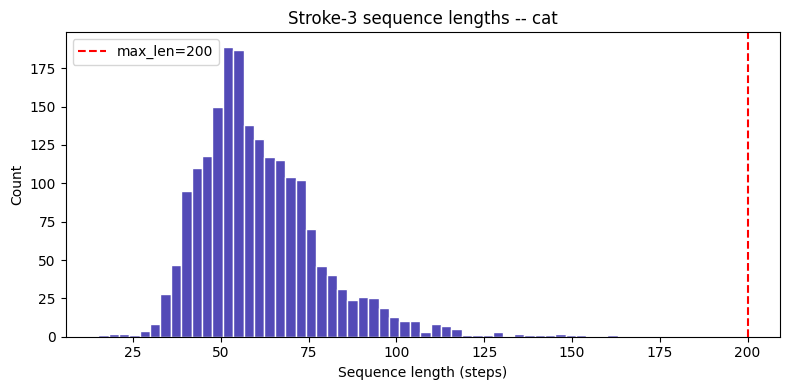

 no of drawingss123202
percentage of drawing with stroke count >200 : 0.08766091459554227


In [10]:
import matplotlib.pyplot as plt

lengths = []
for d in drawings[:2000]:
    s3 = drawing_to_stroke3(d['drawing'])
    lengths.append(len(s3))

lengths = np.array(lengths)
print(f'Mean   : {lengths.mean():.1f}')
print(f'Max    : {lengths.max()}')
print(f'95th % : {np.percentile(lengths, 95):.0f}')

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50, color='#534AB7', edgecolor='white')
plt.axvline(200, color='red', linestyle='--', label='max_len=200')
plt.xlabel('Sequence length (steps)')
plt.ylabel('Count')
plt.title('Stroke-3 sequence lengths -- cat')
plt.legend()
plt.tight_layout()
plt.show()

# TODO: What percentage of drawings are longer than 200 steps?
#       Is 200 a reasonable cutoff for this category?
# YOUR CODE HERE
print(f" no of drawingss{len(drawings)}")
c=0;
for dr in drawings:
    d2=drawing_to_stroke3(dr['drawing'])
    if(len(d2)>200):
        c=c+1
print(f"percentage of drawing with stroke count >200 : {c/len(drawings)*100}")

## 6. PyTorch Dataset

Now we wrap everything into a clean `Dataset` class. We will import this directly in Week 3.

In [11]:
import torch
from torch.utils.data import Dataset, DataLoader

class QuickDrawDataset(Dataset):
    def __init__(self, path, max_len=200, max_samples=5000):
        '''
        path        : path to .ndjson file
        max_len     : truncate sequences longer than this
        max_samples : load at most this many drawings
        '''
        self.samples = []
        with open(path) as f:
            for i, line in enumerate(f):
                if i >= max_samples:
                    break
                d  = json.loads(line)
                s3 = drawing_to_stroke3(d['drawing'])
                s3 = normalise_stroke3(s3)
                if len(s3) > max_len:
                    s3 = s3[:max_len]
                self.samples.append(torch.tensor(s3, dtype=torch.float32))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

dataset = QuickDrawDataset('data/cat.ndjson', max_len=200, max_samples=2000)
print(f'Dataset size       : {len(dataset)}')
print(f'First sample shape : {dataset[0].shape}')
print(f'First 4 rows:\n{dataset[0][:4]}')


Dataset size       : 2000
First sample shape : torch.Size([53, 3])
First 4 rows:
tensor([[ 0.0033, -0.1266,  0.0000],
        [-0.7392, -1.8586,  0.0000],
        [-0.6082, -0.8303,  0.0000],
        [ 0.4401,  2.6879,  0.0000]])


In [12]:
loader = DataLoader(dataset, batch_size=1, shuffle=True)
batch  = next(iter(loader))
print('Batch shape:', batch.shape)   # (1, seq_len, 3)

# TODO: Why is batch_size=1 limiting for training?
#       What problem arises with batch_size=32 when sequences have different lengths?
#       (We will solve this with padding in Week 3.)
# YOUR CODE HERE


Batch shape: torch.Size([1, 59, 3])


## Done!

You have a full data pipeline from raw `.ndjson` to PyTorch tensors.
Next: `stroke_visualiser.ipynb`